dataset 深度体检报告

[1] 数据总量:
 - 总行数 (样本数): 111452
 - 总列数 (特征数): 39

[2] 列名与数据类型:
AppID                          object
Name                           object
Release date                   object
Estimated owners                int64
Peak CCU                        int64
Required age                  float64
Price                           int64
DiscountDLC count               int64
About the game                 object
Supported languages            object
Full audio languages           object
Reviews                        object
Header image                   object
Website                        object
Support url                    object
Support email                  object
Windows                          bool
Mac                              bool
Linux                            bool
Metacritic score                int64
Metacritic url                 object
User score                      int64
Positive                        int64
Negative                        int64
Score rank

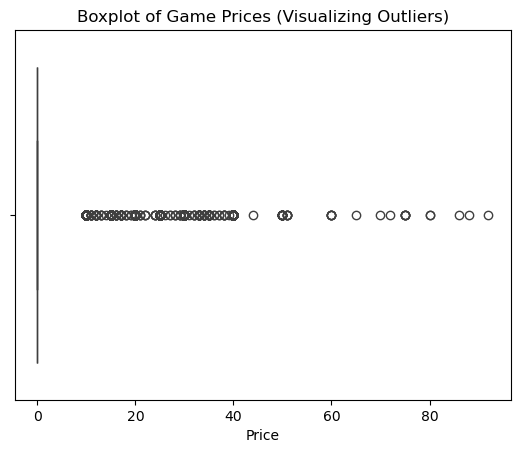

In [9]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 定义体检函数
def check_dataset_health(df):
    print("="*50)
    print("dataset 深度体检报告")
    print("="*50)
    
    rows, cols = df.shape
    print(f"\n[1] 数据总量:")
    print(f" - 总行数 (样本数): {rows}")
    print(f" - 总列数 (特征数): {cols}")
    
    print(f"\n[2] 列名与数据类型:")
    print(df.dtypes)
    
    print(f"\n[3] 缺失值 (NaN) 统计:")
    missing_values = df.isnull().sum()
    missing_values = missing_values[missing_values > 0]
    
    if len(missing_values) == 0:
        print(" - 太棒了！数据集中没有发现 NaN 值。")
    else:
        for col, count in missing_values.items():
            percentage = (count / rows) * 100
            print(f" - {col}: 缺失 {count} 条 ({percentage:.2f}%)")
            
    print(f"\n[4] 异常值 (Outliers) 检测 (基于 IQR 方法):")
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    
    found_outliers = False
    for col in numeric_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        num_outliers = outliers.shape[0]
        
        if num_outliers > 0:
            found_outliers = True
            print(f" - 列 '{col}': 发现 {num_outliers} 个异常值")
            print(f"   (正常范围: {lower_bound:.2f} ~ {upper_bound:.2f})")
    
    if not found_outliers:
        print(" - 未在数值列中检测到明显的统计学异常值。")
    print("\n" + "="*50)

df = pd.read_csv('games.csv') 
check_dataset_health(df)
if 'Price' in df.columns:
    sns.boxplot(x=df['Price']) 
    plt.title("Boxplot of Game Prices (Visualizing Outliers)")
    plt.show()
else:
    print("错误：找不到名为 'Price' 的列，请检查上方体检报告中的列名列表。")


In [17]:
import pandas as pd
import numpy as np
import re 
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD

def clean_and_prepare_data(file_path):
    print(">>> [Step 0] Loading Dataset...")
    df = pd.read_csv(file_path)
    
    # 1. 确保选取所有需要的列
    cols_needed = ['Price', 'Required age', 'DiscountDLC count', 
                   'Windows', 'Mac', 'Linux', 'Genres', 
                   'Positive', 'Negative', 
                   'Categories', 'Supported languages', 'Achievements',
                   'About the game', 'Name']
    
    existing_cols = [c for c in cols_needed if c in df.columns]
    df = df[existing_cols].copy()

    # 1. 基础构建与过滤

    print("\n>>> [Step 1] Creating Target & Filtering Noise...")
    df['total_reviews'] = df['Positive'] + df['Negative']
    df['positive_ratio'] = df['Positive'] / (df['total_reviews'] + 1e-5)
    
    initial_count = len(df)
    df = df[df['total_reviews'] >= 50].copy()
    print(f"   - Filtered: Reviews >= 50 (Dropped {initial_count - len(df)} rows)")

    # 2. 缺失值处理

    print("\n>>> [Step 2] Handling Missing Values...")
    str_cols = ['Genres', 'Categories', 'Supported languages', 'About the game', 'Name']
    for col in str_cols:
        if col in df.columns:
            df[col] = df[col].fillna('')
    
    if 'Price' in df.columns:
        df['Price'] = df['Price'].fillna(df['Price'].median())

    # 3. 基础特征工程

    print("\n>>> [Step 3] Basic Feature Engineering...")

    # A: 语言数量
    if 'Supported languages' in df.columns:
        df['Lang_Count'] = df['Supported languages'].apply(lambda x: len(str(x).split(',')))
        df.drop(columns=['Supported languages'], inplace=True)

    # B: 单人/多人模式
    if 'Categories' in df.columns:
        df['Is_SinglePlayer'] = df['Categories'].apply(lambda x: 1 if 'Single-player' in str(x) else 0)
        df['Is_MultiPlayer'] = df['Categories'].apply(lambda x: 1 if 'Multi-player' in str(x) else 0)
        df.drop(columns=['Categories'], inplace=True)

    # C: 成就系统 (Log)
    if 'Achievements' in df.columns:
        df['Achievements'] = np.log1p(df['Achievements'])

    # 借鉴 Kaggle 报告的新特征

    print("\n>>> [Step 3.2] Adding Insights from Kaggle Report...")
    
    # 1. 描述长度 (Description Length)
    df['Desc_Length'] = df['About the game'].apply(lambda x: len(str(x).split()))
    df['Desc_Length'] = np.log1p(df['Desc_Length'])
    
    # 2. 操作系统支持计数
    df['OS_Count'] = df['Windows'].astype(int) + df['Mac'].astype(int) + df['Linux'].astype(int)
    
    # 3. CJK 字符检测
    def has_cjk(text):
        cjk_pattern = re.compile(r'[\u4E00-\u9FFF\u3040-\u309F\u30A0-\u30FF\uAC00-\uD7AF]')
        return 1 if cjk_pattern.search(str(text)) else 0
        
    df['Has_CJK'] = df['About the game'].apply(has_cjk)

 
    # 文本挖掘 (TF-IDF + SVD)
    print("\n>>> [Step 3.5] Applying NLP (TF-IDF + SVD)...")
    
    df['text_content'] = df['Name'] + " " + df['About the game']

    df['text_content'] = df['text_content'].astype(str).str.replace(r'[^a-zA-Z\s]', '', regex=True).str.lower()
    
    tfidf = TfidfVectorizer(stop_words='english', max_features=1000)
    tfidf_matrix = tfidf.fit_transform(df['text_content'])
    
    svd = TruncatedSVD(n_components=20, random_state=42)
    text_features = svd.fit_transform(tfidf_matrix)
    
    df.reset_index(drop=True, inplace=True)
    text_df = pd.DataFrame(text_features, columns=[f'Text_Topic_{i}' for i in range(20)])
    df = pd.concat([df, text_df], axis=1)
    
    df.drop(columns=['About the game', 'Name', 'text_content'], inplace=True)

    # 5. Log 变换与去极值
    print("\n>>> [Step 4] Log Transform & Capping...")
    
    def cap_outliers(series):
        upper = series.quantile(0.99)
        return np.where(series > upper, upper, series)

    for col in ['Price', 'DiscountDLC count']:
        if col in df.columns:
            df[col] = cap_outliers(df[col]) 
            df[col] = np.log1p(df[col])

    # 6. One-Hot Encoding
    print("\n>>> [Step 5] Encoding...")
    if 'Genres' in df.columns:
        df['Main_Genre'] = df['Genres'].apply(lambda x: x.split(',')[0])
        df = pd.get_dummies(df, columns=['Main_Genre'], prefix='Genre')
        df.drop(columns=['Genres'], inplace=True)
    
    cols_to_drop = ['Positive', 'Negative', 'total_reviews']
    df.drop(columns=[c for c in cols_to_drop if c in df.columns], inplace=True)
    
    for col in ['Windows', 'Mac', 'Linux', 'Is_SinglePlayer', 'Is_MultiPlayer']:
        if col in df.columns:
            df[col] = df[col].astype(int)

    print("\n" + "="*40)
    print(f"Data Cleaning Complete! Final Shape: {df.shape}")
    print("="*40)
    return df

file_path = 'games.csv' 
df_clean = clean_and_prepare_data(file_path)

print("新特征预览:")
print(df_clean[['Desc_Length', 'OS_Count', 'Has_CJK']].head())
import pandas as pd

pd.set_option('display.max_columns', None)

print("所有特征预览：")
print(df_clean.head())

print("\n=== 特征清单 (共 {} 个) ===".format(len(df_clean.columns)))
print(df_clean.columns.tolist())

>>> [Step 0] Loading Dataset...

>>> [Step 1] Creating Target & Filtering Noise...
   - Filtered: Reviews >= 50 (Dropped 86325 rows)

>>> [Step 2] Handling Missing Values...

>>> [Step 3] Basic Feature Engineering...

>>> [Step 3.2] Adding Insights from Kaggle Report...

>>> [Step 3.5] Applying NLP (TF-IDF + SVD)...

>>> [Step 4] Log Transform & Capping...

>>> [Step 5] Encoding...

Data Cleaning Complete! Final Shape: (25127, 62)
新特征预览:
   Desc_Length  OS_Count  Has_CJK
0     4.477337         2        0
1     4.753590         2        0
2     5.683580         1        0
3     5.129899         1        0
4     5.438079         3        0
所有特征预览：
   Price  Required age  DiscountDLC count  Windows  Mac  Linux  Achievements  \
0    0.0          0.99                0.0        1    1      0      2.564949   
1    0.0          0.00                0.0        1    1      0      2.890372   
2    0.0          0.00                0.0        1    0      0      0.000000   
3    0.0         14.99    

当前数据量: 25127
特征总数: 62 (应该为 62)

所有特征列名预览:
['Price', 'Required age', 'DiscountDLC count', 'Windows', 'Mac', 'Linux', 'Achievements', 'positive_ratio', 'Lang_Count', 'Is_SinglePlayer', 'Is_MultiPlayer', 'Desc_Length', 'OS_Count', 'Has_CJK', 'Text_Topic_0', 'Text_Topic_1', 'Text_Topic_2', 'Text_Topic_3', 'Text_Topic_4', 'Text_Topic_5', 'Text_Topic_6', 'Text_Topic_7', 'Text_Topic_8', 'Text_Topic_9', 'Text_Topic_10', 'Text_Topic_11', 'Text_Topic_12', 'Text_Topic_13', 'Text_Topic_14', 'Text_Topic_15', 'Text_Topic_16', 'Text_Topic_17', 'Text_Topic_18', 'Text_Topic_19', 'Genre_', 'Genre_Accounting', 'Genre_Action', 'Genre_Adventure', 'Genre_Animation & Modeling', 'Genre_Audio Production', 'Genre_Casual', 'Genre_Design & Illustration', 'Genre_Early Access', 'Genre_Education', 'Genre_Free to Play', 'Genre_Game Development', 'Genre_Gore', 'Genre_Indie', 'Genre_Massively Multiplayer', 'Genre_Nudity', 'Genre_Photo Editing', 'Genre_RPG', 'Genre_Racing', 'Genre_Sexual Content', 'Genre_Simulation', 'G

/Users/zhouzhiqian/miniconda3/envs/nav_env/lib/python3.10/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_18 (Dense)                │ (None, 128)            │         7,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,305 (71.50 KB)

 Trainable params: 18,305 (71.50 KB)

 Non-trainable params: 0 (0.00 B)


>>> [Step 3] Training Start...
Epoch 1/30
503/503 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0310 - mae: 0.1374 - val_loss: 0.0248 - val_mae: 0.1270
Epoch 2/30
503/503 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0253 - mae: 0.1249 - val_loss: 0.0241 - val_mae: 0.1247
Epoch 3/30
503/503 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0238 - mae: 0.1206 - val_loss: 0.0240 - val_mae: 0.1248
Epoch 4/30
503/503 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0238 - mae: 0.1204 - val_loss: 0.0239 - val_mae: 0.1248
Epoch 5/30
503/503 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0223 - mae: 0.1163 - val_loss: 0.0236 - val_mae: 0.1237
Epoch 6/30
503/503 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0235 - mae: 0.1198 - val_loss: 0.0234 - val_mae: 0.1215
Epoch 7/30
503/503 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0224 - mae: 0.1160 - val_loss: 0.0233 - val_mae: 0.1216
Epoch 8/30
503/503 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0221 - mae: 0.1159 - val_loss: 0.0234 - val_mae: 0.1226
Epoch 9/30
503/503 ━━━━━

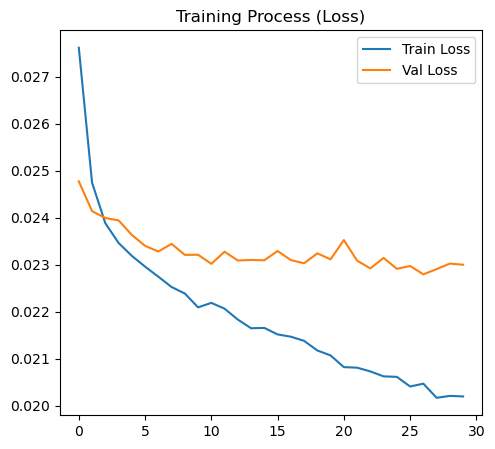

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
import keras
from sklearn.metrics import r2_score

print(f"当前数据量: {len(df_clean)}")
print(f"特征总数: {df_clean.shape[1]} (应该为 62)") 
print("\n所有特征列名预览:")
print(df_clean.columns.tolist())

Sequential = keras.models.Sequential
Dense = keras.layers.Dense
Dropout = keras.layers.Dropout
Adam = keras.optimizers.Adam

# 1. 数据切分与标准化
print("\n>>> [Step 1] Splitting & Scaling Data...")

target_col = 'positive_ratio'
X = df_clean.drop(columns=[target_col])
y = df_clean[target_col]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"   - Training Set: {X_train.shape[0]} samples")
print(f"   - Testing Set:  {X_test.shape[0]} samples")

# 2. 构建神经网络 
print("\n>>> [Step 2] Building Model...")

def build_model(input_dim):
    model = Sequential([
        Dense(128, activation='relu', input_shape=(input_dim,)), 
        Dropout(0.3), 
        Dense(64, activation='relu'),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
    return model

input_dim = X_train_scaled.shape[1]
model = build_model(input_dim)
model.summary()

# 3. 训练模型

print("\n>>> [Step 3] Training Start...")

history = model.fit(
    X_train_scaled, y_train,
    epochs=30, 
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# 4. 最终评估与画图

print("\n>>> [Step 4] Evaluation...")

# 预测
y_pred = model.predict(X_test_scaled)
test_loss, test_mae = model.evaluate(X_test_scaled, y_test, verbose=0)
r2 = r2_score(y_test, y_pred)

print(f"\n★ Final Results (Ultimate Model):")
print(f"   - MAE: {test_mae:.4f}")
print(f"   - R² Score: {r2:.4f}")

# 画 Loss 曲线
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Training Process (Loss)')
plt.legend()


158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


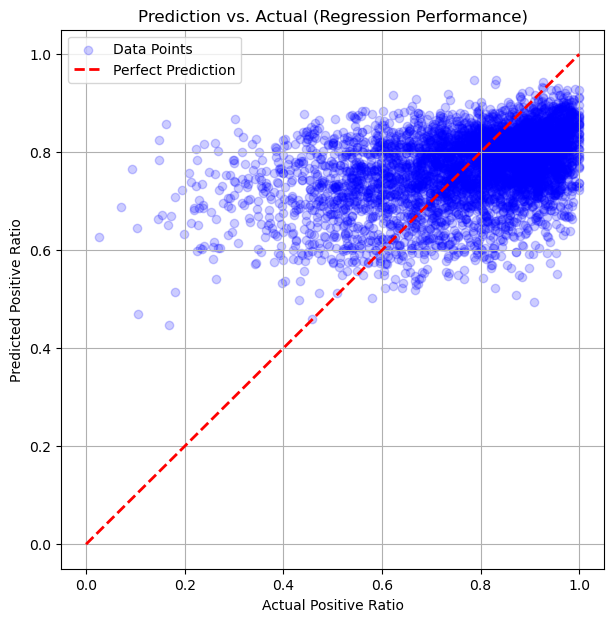

In [22]:
 import matplotlib.pyplot as plt

# 1. 用测试集进行预测
predictions = model.predict(X_test_scaled)

# 2. 画散点图 
plt.figure(figsize=(7, 7))
plt.scatter(y_test, predictions, alpha=0.2, color='blue', label='Data Points')

# 3. 画对角线
plt.plot([0, 1], [0, 1], color='red', linestyle='--', linewidth=2, label='Perfect Prediction')

plt.title('Prediction vs. Actual (Regression Performance)')
plt.xlabel('Actual Positive Ratio')    
plt.ylabel('Predicted Positive Ratio')  
plt.legend()
plt.grid(True)
plt.show()

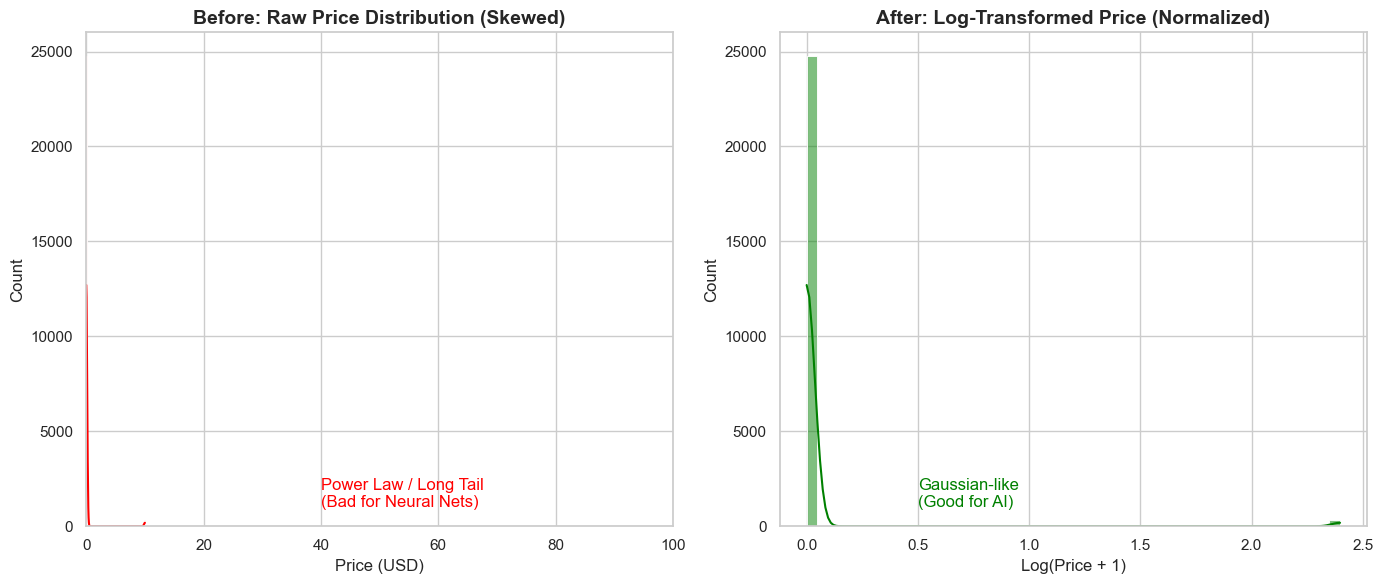

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set(style="whitegrid")
plt.figure(figsize=(14, 6))

original_price = np.expm1(df_clean['Price'])

plt.subplot(1, 2, 1)
sns.histplot(original_price, bins=50, kde=True, color='red')
plt.title('Before: Raw Price Distribution (Skewed)', fontsize=14, fontweight='bold')
plt.xlabel('Price (USD)')
plt.ylabel('Count')
plt.xlim(0, 100) 
plt.text(40, 1000, 'Power Law / Long Tail\n(Bad for Neural Nets)', color='red', fontsize=12)
plt.subplot(1, 2, 2)
sns.histplot(df_clean['Price'], bins=50, kde=True, color='green')
plt.title('After: Log-Transformed Price (Normalized)', fontsize=14, fontweight='bold')
plt.xlabel('Log(Price + 1)')
plt.ylabel('Count')
plt.text(0.5, 1000, 'Gaussian-like\n(Good for AI)', color='green', fontsize=12)

plt.tight_layout()
plt.show()

正在绘制以下 9 个特征的相关性热力图: 
['positive_ratio', 'Price', 'Desc_Length', 'Lang_Count', 'OS_Count', 'Achievements', 'Is_SinglePlayer', 'Is_MultiPlayer', 'Has_CJK']


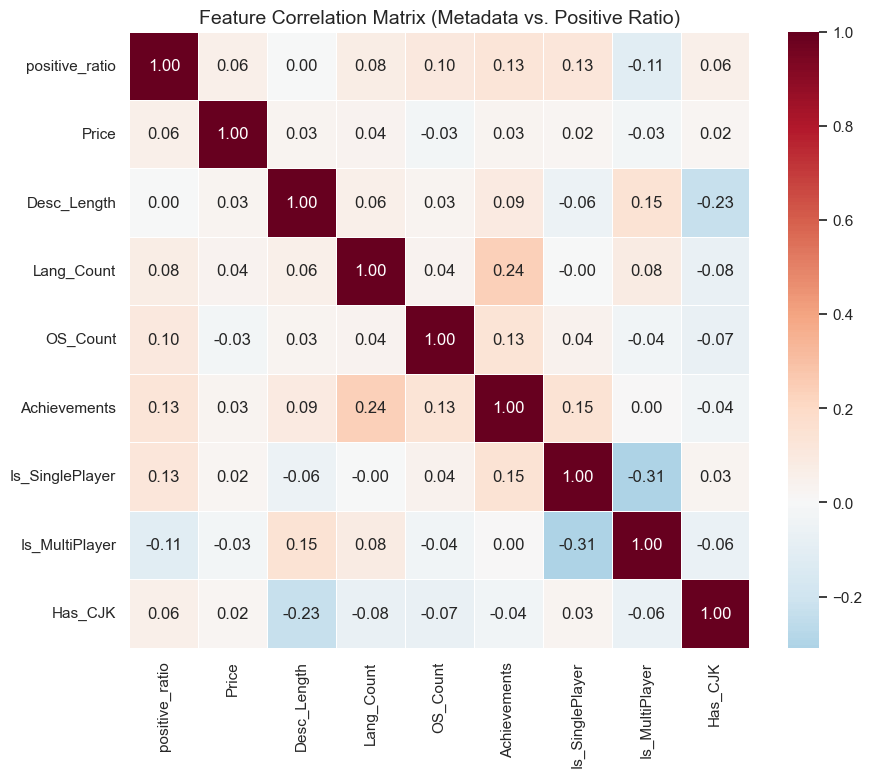

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

target_cols = [
    'positive_ratio',    
    'Price',             
    'Desc_Length',       
    'Lang_Count',        
    'OS_Count',          
    'Achievements',      
    'Is_SinglePlayer',   
    'Is_MultiPlayer',    
    'Has_CJK'            
]


cols_to_plot = [c for c in target_cols if c in df_clean.columns]

print(f"正在绘制以下 {len(cols_to_plot)} 个特征的相关性热力图: \n{cols_to_plot}")

corr_matrix = df_clean[cols_to_plot].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, 
            annot=True,       
            cmap='RdBu_r',    
            center=0,         
            fmt=".2f",        
            linewidths=0.5)   

plt.title('Feature Correlation Matrix (Metadata vs. Positive Ratio)', fontsize=14)
plt.show()

In [30]:
import pandas as pd

stats_features = ['Price', 'positive_ratio', 'Desc_Length', 'OS_Count', 'Lang_Count']
cols_to_summary = [c for c in stats_features if c in df_clean.columns]
summary_table = df_clean[cols_to_summary].describe().T[['mean', '50%', 'min', 'max']]
summary_table['variance'] = df_clean[cols_to_summary].var()
summary_table = summary_table[['mean', '50%', 'variance', 'min', 'max']]
summary_table.columns = ['Mean', 'Median', 'Variance', 'Min', 'Max']

print(">>> Table 1: Summary Statistics of Key Features")
print(summary_table)

>>> Table 1: Summary Statistics of Key Features
                    Mean    Median   Variance   Min         Max
Price           0.033878  0.000000   0.080091  0.00    2.397895
positive_ratio  0.779313  0.817073   0.026651  0.02    1.000000
Desc_Length     5.306119  5.356586   0.541406  0.00    7.950502
OS_Count        1.489633  1.000000   0.586685  1.00    3.000000
Lang_Count      5.097146  3.000000  28.903441  1.00  103.000000


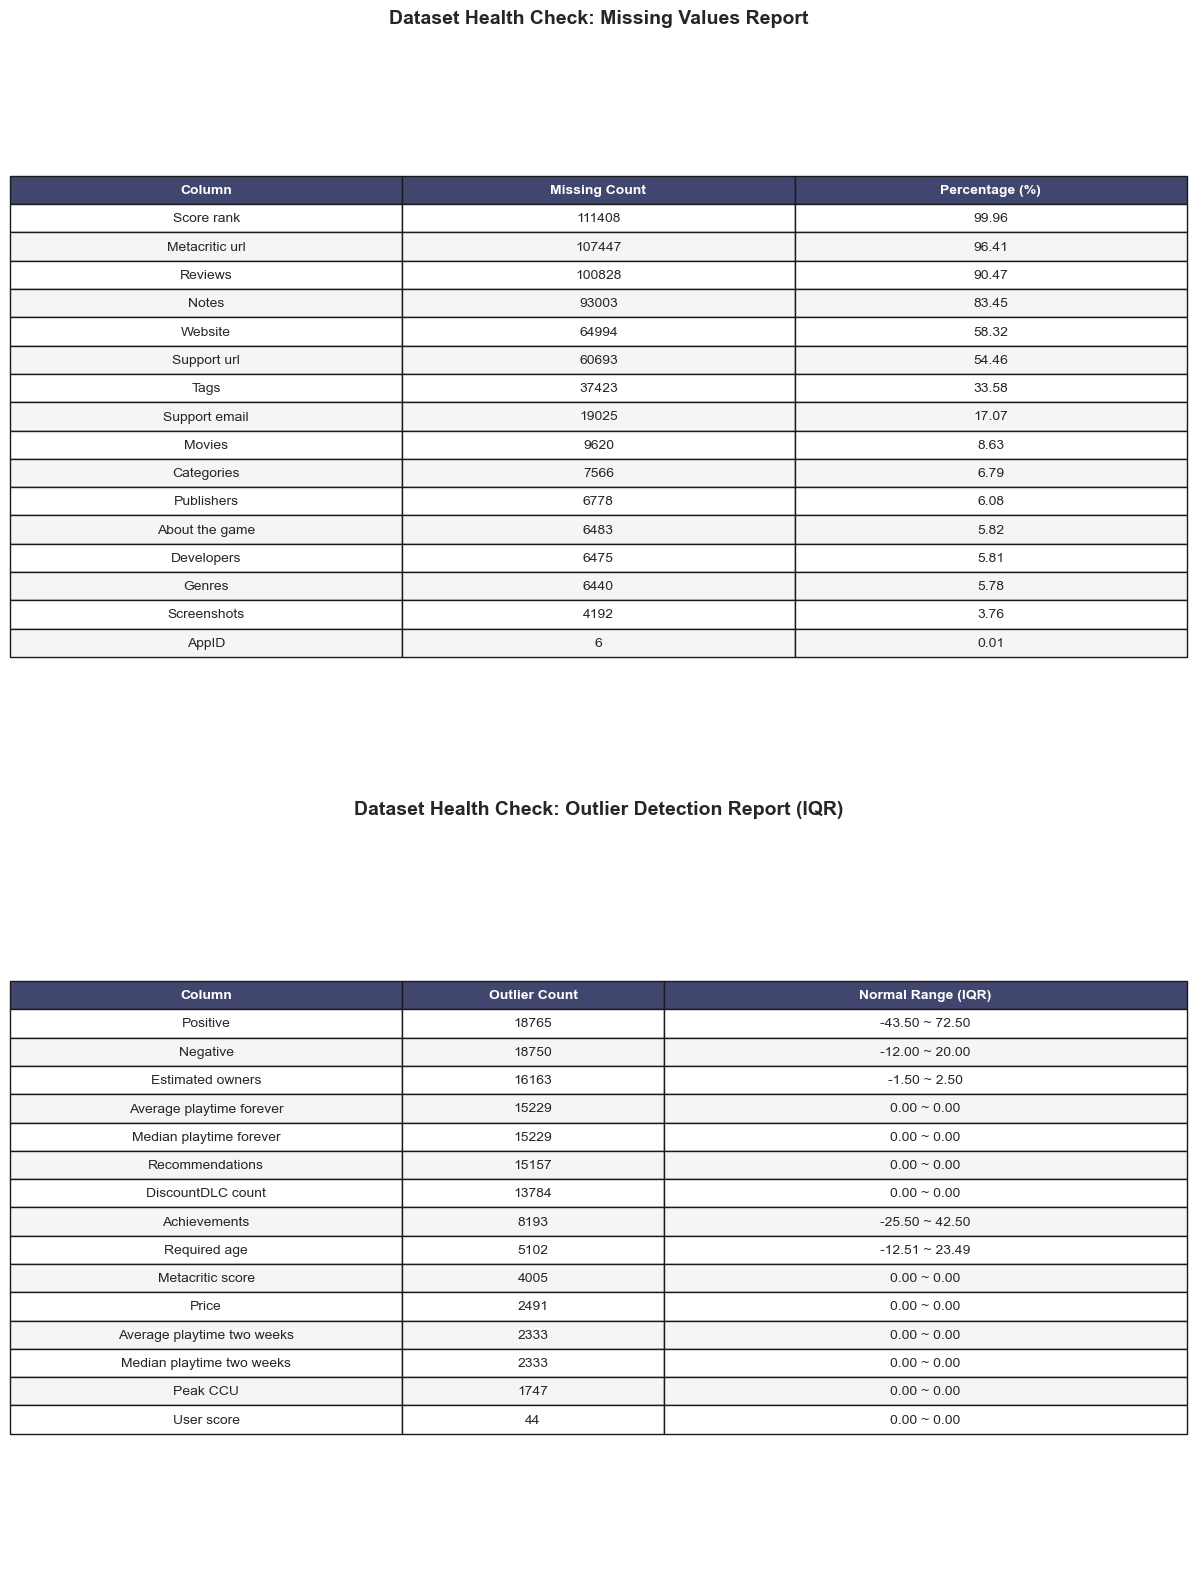

In [31]:
import pandas as pd
import matplotlib.pyplot as plt

missing_data = {
    'Column': ['AppID', 'About the game', 'Reviews', 'Website', 'Support url', 'Support email', 'Metacritic url', 'Score rank', 'Notes', 'Developers', 'Publishers', 'Categories', 'Genres', 'Tags', 'Screenshots', 'Movies'],
    'Missing Count': [6, 6483, 100828, 64994, 60693, 19025, 107447, 111408, 93003, 6475, 6778, 7566, 6440, 37423, 4192, 9620],
    'Percentage (%)': [0.01, 5.82, 90.47, 58.32, 54.46, 17.07, 96.41, 99.96, 83.45, 5.81, 6.08, 6.79, 5.78, 33.58, 3.76, 8.63]
}

outlier_data = {
    'Column': ['Estimated owners', 'Peak CCU', 'Required age', 'Price', 'DiscountDLC count', 'Metacritic score', 'User score', 'Positive', 'Negative', 'Achievements', 'Recommendations', 'Average playtime forever', 'Average playtime two weeks', 'Median playtime forever', 'Median playtime two weeks'],
    'Outlier Count': [16163, 1747, 5102, 2491, 13784, 4005, 44, 18765, 18750, 8193, 15157, 15229, 2333, 15229, 2333],
    'Normal Range (IQR)': ['-1.50 ~ 2.50', '0.00 ~ 0.00', '-12.51 ~ 23.49', '0.00 ~ 0.00', '0.00 ~ 0.00', '0.00 ~ 0.00', '0.00 ~ 0.00', '-43.50 ~ 72.50', '-12.00 ~ 20.00', '-25.50 ~ 42.50', '0.00 ~ 0.00', '0.00 ~ 0.00', '0.00 ~ 0.00', '0.00 ~ 0.00', '0.00 ~ 0.00']
}

df_missing = pd.DataFrame(missing_data).sort_values(by='Percentage (%)', ascending=False)
df_outliers = pd.DataFrame(outlier_data).sort_values(by='Outlier Count', ascending=False)

def plot_visual_table(df_miss, df_out):
    fig, axes = plt.subplots(2, 1, figsize=(12, 16)) 
    
    def draw_table(ax, df, title, col_widths):
        ax.axis('off')
        table = ax.table(cellText=df.values, colLabels=df.columns, loc='center', cellLoc='center', colWidths=col_widths)
        table.auto_set_font_size(False)
        table.set_fontsize(10)
        table.scale(1.2, 1.3) 
        for (i, j), cell in table.get_celld().items():
            if i == 0: # 表头
                cell.set_text_props(weight='bold', color='white')
                cell.set_facecolor('#40466e') 
            else:
                if i % 2 == 0: 
                    cell.set_facecolor('#f5f5f5')
        
        ax.set_title(title, fontsize=14, fontweight='bold', pad=20)

    draw_table(axes[0], df_miss, 'Dataset Health Check: Missing Values Report', [0.3, 0.3, 0.3])

    draw_table(axes[1], df_out, 'Dataset Health Check: Outlier Detection Report (IQR)', [0.3, 0.2, 0.4])

    plt.tight_layout()
    plt.show()

plot_visual_table(df_missing, df_outliers)